# Bias-Variance Tradeoff and Regularization

Understanding model complexity, bias, variance, and regularization techniques.

📺 **Video Lecture:** [https://youtu.be/VsvnNYoMDZY](https://youtu.be/VsvnNYoMDZY)

## Overview

This notebook covers:
- Bias-variance tradeoff visualization
- Underfitting vs Overfitting
- L1 (Lasso) regularization
- L2 (Ridge) regularization
- Elastic Net
- Early stopping
- Dropout simulation
- Training vs validation curves

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split

np.random.seed(42)
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')


## 1. Create Synthetic Data

In [3]:
# Generate synthetic data with underlying trend
n_samples = 100
X = np.linspace(0, 10, n_samples).reshape(-1, 1)
true_function = 0.5 * X.ravel() + 0.1 * X.ravel()**2 - 0.01 * X.ravel()**3
y = true_function + np.random.normal(0, 2, n_samples)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Create test data for smooth curves
X_smooth = np.linspace(0, 10, 300).reshape(-1, 1)
y_true_smooth = 0.5 * X_smooth.ravel() + 0.1 * X_smooth.ravel()**2 - 0.01 * X_smooth.ravel()**3

print(f'Training set size: {X_train.shape[0]}')
print(f'Test set size: {X_test.shape[0]}')


Training set size: 70
Test set size: 30


## 2. Bias-Variance Tradeoff: Polynomial Regression

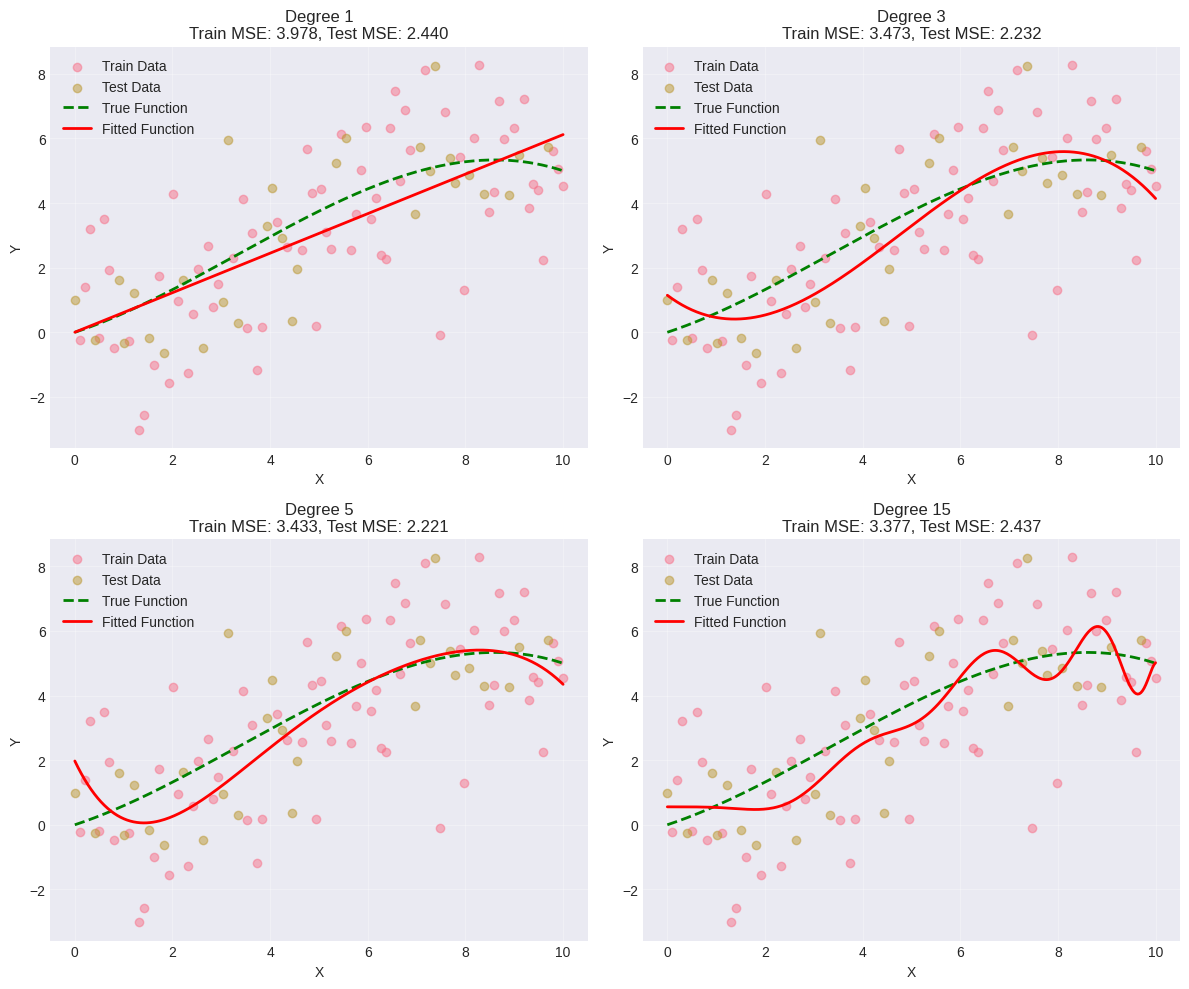

In [4]:
# Fit polynomials of different degrees
degrees = [1, 3, 5, 15]
models = []

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.ravel()

for idx, degree in enumerate(degrees):
    poly = PolynomialFeatures(degree=degree)
    X_train_poly = poly.fit_transform(X_train)
    X_test_poly = poly.transform(X_test)
    X_smooth_poly = poly.transform(X_smooth)
    
    model = LinearRegression()
    model.fit(X_train_poly, y_train)
    models.append(model)
    
    y_train_pred = model.predict(X_train_poly)
    y_test_pred = model.predict(X_test_poly)
    y_smooth_pred = model.predict(X_smooth_poly)
    
    train_mse = mean_squared_error(y_train, y_train_pred)
    test_mse = mean_squared_error(y_test, y_test_pred)
    
    ax = axes[idx]
    ax.scatter(X_train, y_train, alpha=0.5, label='Train Data')
    ax.scatter(X_test, y_test, alpha=0.5, label='Test Data')
    ax.plot(X_smooth, y_true_smooth, 'g--', label='True Function', linewidth=2)
    ax.plot(X_smooth, y_smooth_pred, 'r-', label='Fitted Function', linewidth=2)
    ax.set_title(f'Degree {degree}\nTrain MSE: {train_mse:.3f}, Test MSE: {test_mse:.3f}')
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## 3. Underfitting vs Overfitting

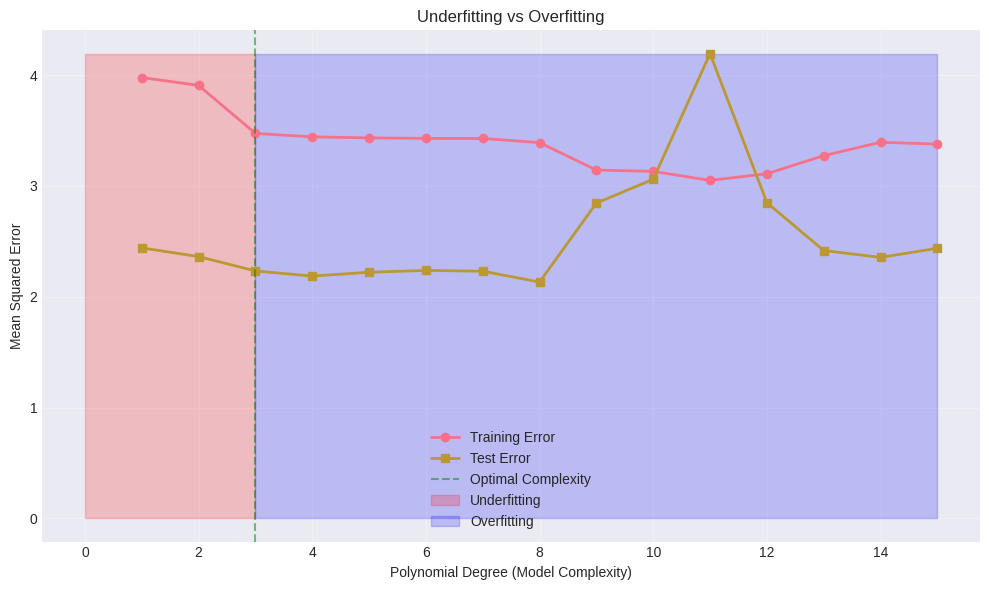

In [5]:
# Train models with different polynomial degrees
degrees_range = list(range(1, 16))
train_errors = []
test_errors = []

for degree in degrees_range:
    poly = PolynomialFeatures(degree=degree)
    X_train_poly = poly.fit_transform(X_train)
    X_test_poly = poly.transform(X_test)
    
    model = LinearRegression()
    model.fit(X_train_poly, y_train)
    
    train_mse = mean_squared_error(y_train, model.predict(X_train_poly))
    test_mse = mean_squared_error(y_test, model.predict(X_test_poly))
    
    train_errors.append(train_mse)
    test_errors.append(test_mse)

# Plot
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(degrees_range, train_errors, 'o-', label='Training Error', linewidth=2, markersize=6)
ax.plot(degrees_range, test_errors, 's-', label='Test Error', linewidth=2, markersize=6)
ax.axvline(x=3, color='g', linestyle='--', alpha=0.5, label='Optimal Complexity')
ax.fill_between([0, 3], 0, max(test_errors), alpha=0.2, color='red', label='Underfitting')
ax.fill_between([3, 15], 0, max(test_errors), alpha=0.2, color='blue', label='Overfitting')
ax.set_xlabel('Polynomial Degree (Model Complexity)')
ax.set_ylabel('Mean Squared Error')
ax.set_title('Underfitting vs Overfitting')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## 4. L1 Regularization (Lasso)

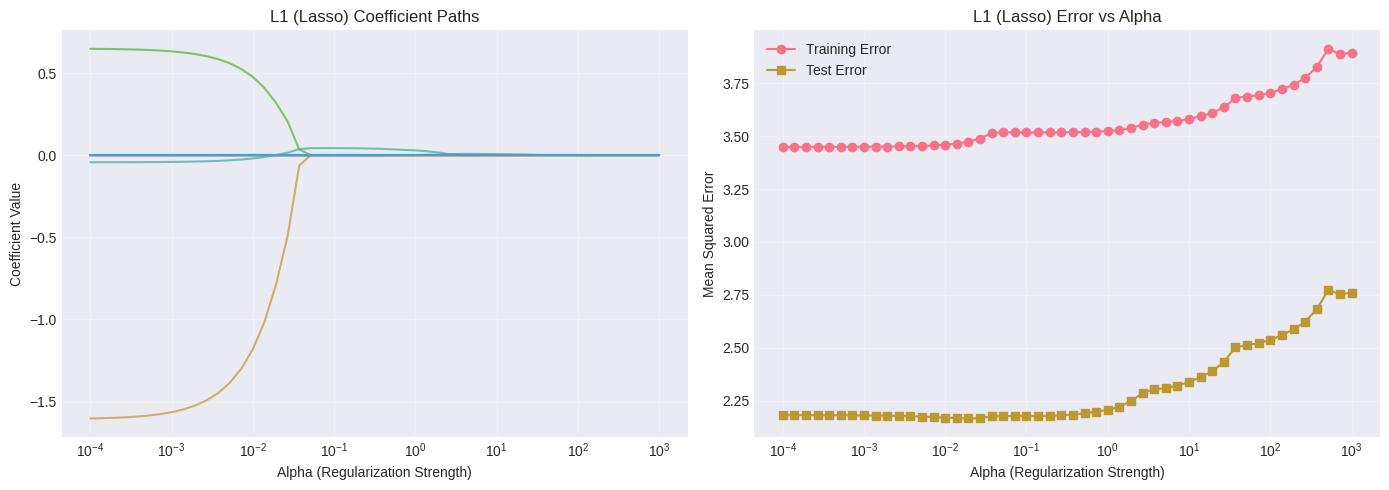

In [6]:
# L1 (Lasso) regularization
alphas = np.logspace(-4, 3, 50)
lasso_coefs = []
lasso_train_errors = []
lasso_test_errors = []

poly = PolynomialFeatures(degree=10)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

for alpha in alphas:
    lasso = Lasso(alpha=alpha, max_iter=10000)
    lasso.fit(X_train_poly, y_train)
    
    lasso_coefs.append(lasso.coef_)
    lasso_train_errors.append(mean_squared_error(y_train, lasso.predict(X_train_poly)))
    lasso_test_errors.append(mean_squared_error(y_test, lasso.predict(X_test_poly)))

# Plot coefficient paths
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for i in range(len(lasso_coefs[0])):
    coef_path = [coef[i] for coef in lasso_coefs]
    axes[0].plot(alphas, coef_path, alpha=0.7)
axes[0].set_xscale('log')
axes[0].set_xlabel('Alpha (Regularization Strength)')
axes[0].set_ylabel('Coefficient Value')
axes[0].set_title('L1 (Lasso) Coefficient Paths')
axes[0].grid(True, alpha=0.3)

axes[1].plot(alphas, lasso_train_errors, 'o-', label='Training Error')
axes[1].plot(alphas, lasso_test_errors, 's-', label='Test Error')
axes[1].set_xscale('log')
axes[1].set_xlabel('Alpha (Regularization Strength)')
axes[1].set_ylabel('Mean Squared Error')
axes[1].set_title('L1 (Lasso) Error vs Alpha')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## 5. L2 Regularization (Ridge)

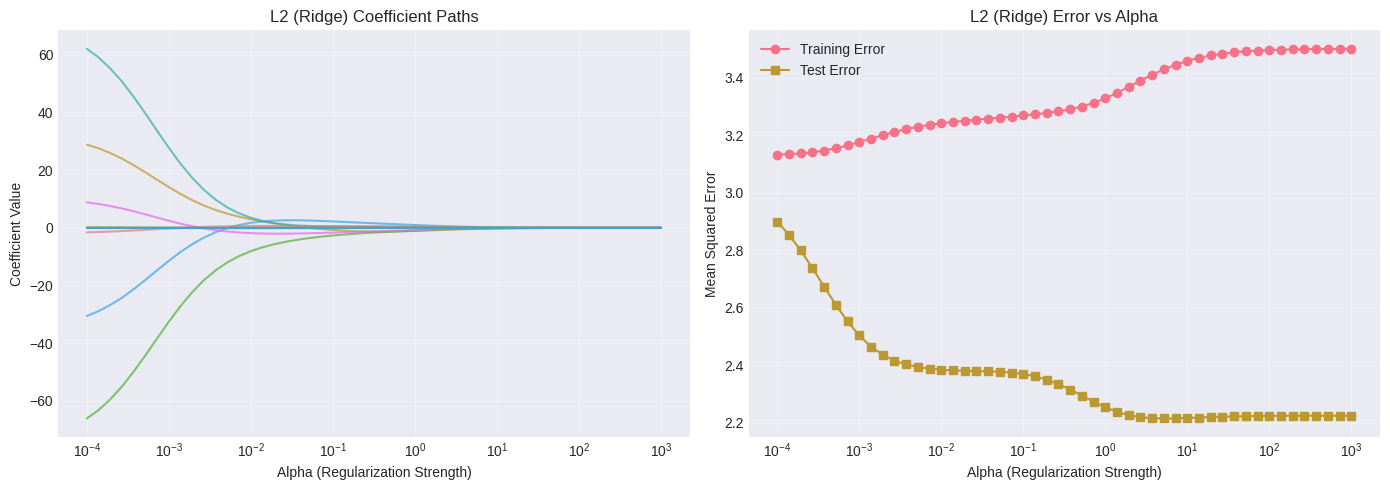

In [7]:
# L2 (Ridge) regularization
ridge_coefs = []
ridge_train_errors = []
ridge_test_errors = []

for alpha in alphas:
    ridge = Ridge(alpha=alpha)
    ridge.fit(X_train_poly, y_train)
    
    ridge_coefs.append(ridge.coef_)
    ridge_train_errors.append(mean_squared_error(y_train, ridge.predict(X_train_poly)))
    ridge_test_errors.append(mean_squared_error(y_test, ridge.predict(X_test_poly)))

# Plot coefficient paths
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for i in range(len(ridge_coefs[0])):
    coef_path = [coef[i] for coef in ridge_coefs]
    axes[0].plot(alphas, coef_path, alpha=0.7)
axes[0].set_xscale('log')
axes[0].set_xlabel('Alpha (Regularization Strength)')
axes[0].set_ylabel('Coefficient Value')
axes[0].set_title('L2 (Ridge) Coefficient Paths')
axes[0].grid(True, alpha=0.3)

axes[1].plot(alphas, ridge_train_errors, 'o-', label='Training Error')
axes[1].plot(alphas, ridge_test_errors, 's-', label='Test Error')
axes[1].set_xscale('log')
axes[1].set_xlabel('Alpha (Regularization Strength)')
axes[1].set_ylabel('Mean Squared Error')
axes[1].set_title('L2 (Ridge) Error vs Alpha')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## 6. L1 vs L2 Comparison

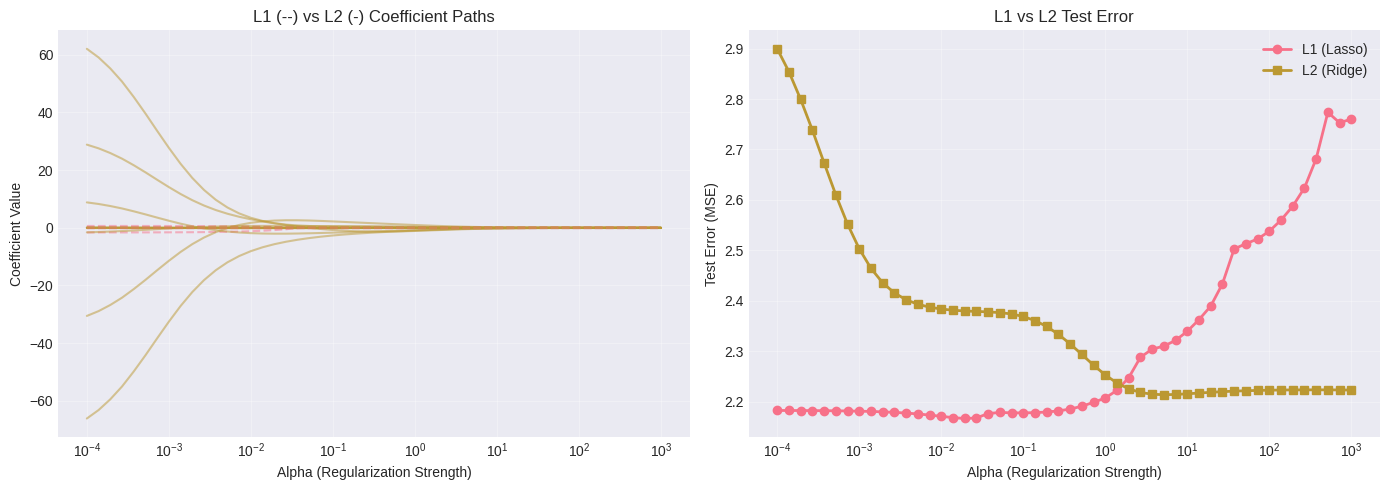

Key difference: L1 shrinks some coefficients to ZERO, L2 shrinks but never to zero


In [8]:
# Direct comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Coefficient paths comparison
for i in range(len(lasso_coefs[0])):
    lasso_path = [coef[i] for coef in lasso_coefs]
    ridge_path = [coef[i] for coef in ridge_coefs]
    axes[0].plot(alphas, lasso_path, '--', alpha=0.5, color='C0')
    axes[0].plot(alphas, ridge_path, '-', alpha=0.5, color='C1')

axes[0].set_xscale('log')
axes[0].set_xlabel('Alpha (Regularization Strength)')
axes[0].set_ylabel('Coefficient Value')
axes[0].set_title('L1 (--) vs L2 (-) Coefficient Paths')
axes[0].grid(True, alpha=0.3)

# Test error comparison
axes[1].plot(alphas, lasso_test_errors, 'o-', label='L1 (Lasso)', linewidth=2)
axes[1].plot(alphas, ridge_test_errors, 's-', label='L2 (Ridge)', linewidth=2)
axes[1].set_xscale('log')
axes[1].set_xlabel('Alpha (Regularization Strength)')
axes[1].set_ylabel('Test Error (MSE)')
axes[1].set_title('L1 vs L2 Test Error')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print('Key difference: L1 shrinks some coefficients to ZERO, L2 shrinks but never to zero')


## 7. Elastic Net Demonstration

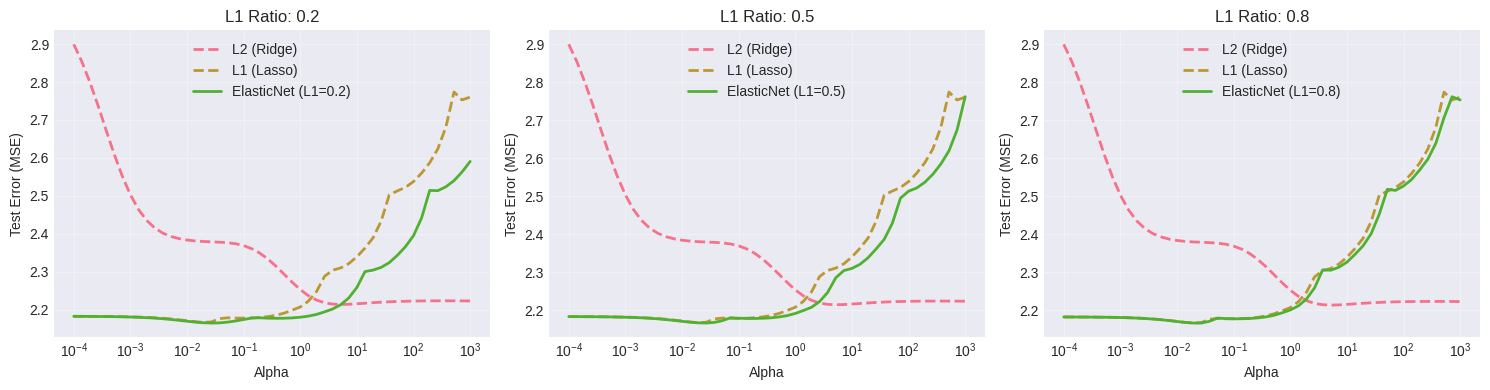

In [9]:
# Elastic Net (combination of L1 and L2)
l1_ratios = [0.2, 0.5, 0.8]
elastic_errors = {}

fig, axes = plt.subplots(1, len(l1_ratios), figsize=(15, 4))

for idx, l1_ratio in enumerate(l1_ratios):
    en_test_errors = []
    
    for alpha in alphas:
        en = ElasticNet(alpha=alpha, l1_ratio=l1_ratio, max_iter=10000)
        en.fit(X_train_poly, y_train)
        en_test_errors.append(mean_squared_error(y_test, en.predict(X_test_poly)))
    
    elastic_errors[l1_ratio] = en_test_errors
    axes[idx].plot(alphas, ridge_test_errors, '--', label='L2 (Ridge)', linewidth=2)
    axes[idx].plot(alphas, lasso_test_errors, '--', label='L1 (Lasso)', linewidth=2)
    axes[idx].plot(alphas, en_test_errors, '-', label=f'ElasticNet (L1={l1_ratio})', linewidth=2)
    axes[idx].set_xscale('log')
    axes[idx].set_xlabel('Alpha')
    axes[idx].set_ylabel('Test Error (MSE)')
    axes[idx].set_title(f'L1 Ratio: {l1_ratio}')
    axes[idx].legend()
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## 8. Early Stopping Simulation

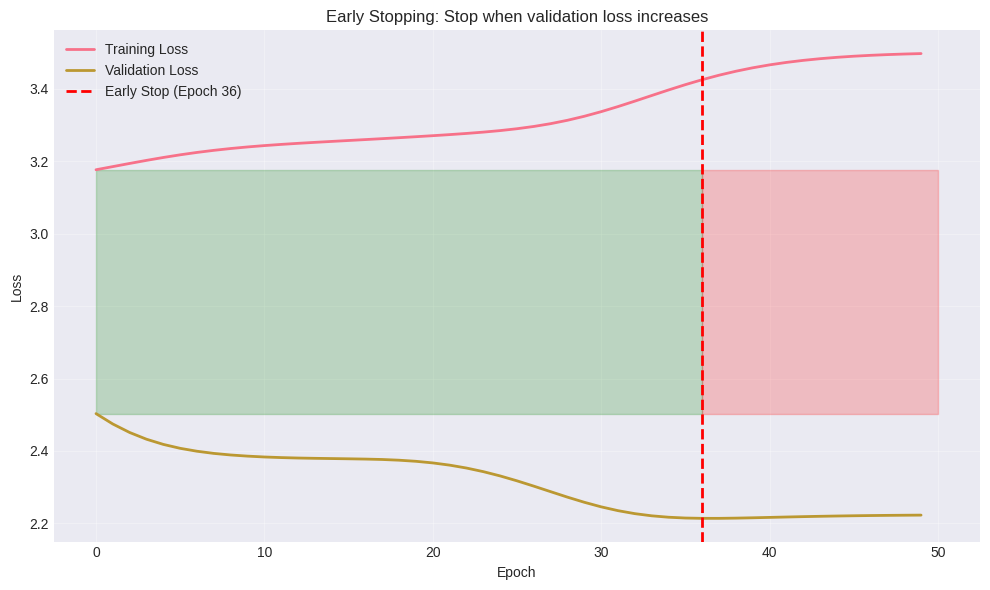

In [10]:
# Simulate early stopping with Ridge regression (more stable)
np.random.seed(42)
n_epochs = 50

train_losses = []
val_losses = []

# Use increasing regularization as proxy for training progress
for epoch, alpha in enumerate(np.logspace(-3, 2, n_epochs)):
    ridge = Ridge(alpha=alpha)
    ridge.fit(X_train_poly, y_train)
    
    train_loss = mean_squared_error(y_train, ridge.predict(X_train_poly))
    val_loss = mean_squared_error(y_test, ridge.predict(X_test_poly))
    
    train_losses.append(train_loss)
    val_losses.append(val_loss)

# Find early stopping point
best_epoch = np.argmin(val_losses)

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(train_losses, label='Training Loss', linewidth=2)
ax.plot(val_losses, label='Validation Loss', linewidth=2)
ax.axvline(x=best_epoch, color='red', linestyle='--', label=f'Early Stop (Epoch {best_epoch})', linewidth=2)
ax.fill_between([0, best_epoch], min(train_losses), max(val_losses), alpha=0.2, color='green')
ax.fill_between([best_epoch, n_epochs], min(train_losses), max(val_losses), alpha=0.2, color='red')
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.set_title('Early Stopping: Stop when validation loss increases')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## 9. Dropout Simulation

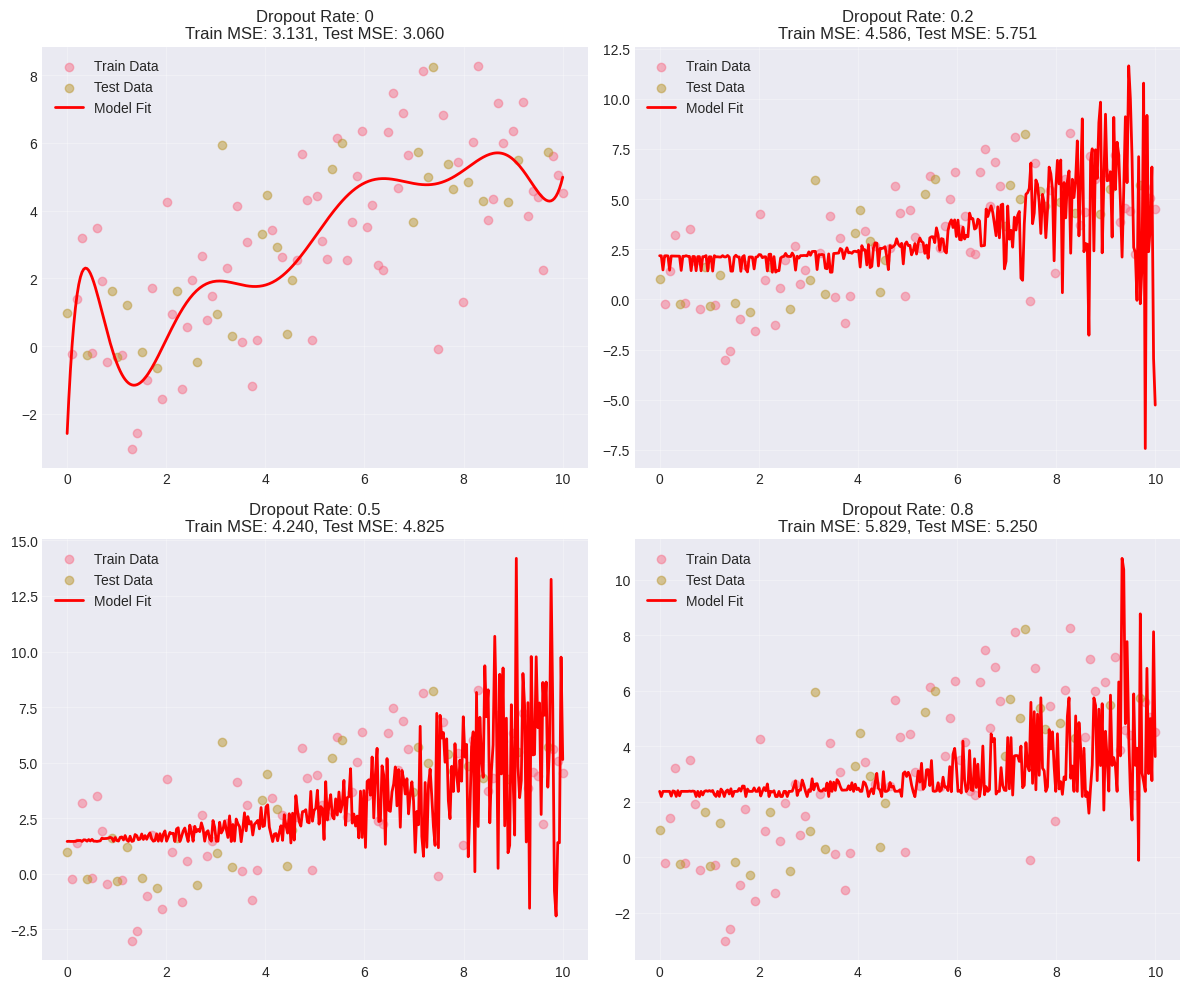

In [11]:
# Simulate dropout effect
dropout_rates = [0, 0.2, 0.5, 0.8]
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.ravel()

for idx, dropout_rate in enumerate(dropout_rates):
    # Simulate dropout: randomly zero out features
    X_train_dropped = X_train_poly.copy()
    X_test_dropped = X_test_poly.copy()
    
    if dropout_rate > 0:
        mask_train = np.random.binomial(1, 1 - dropout_rate, X_train_poly.shape)
        mask_test = np.random.binomial(1, 1 - dropout_rate, X_test_poly.shape)
        X_train_dropped = X_train_poly * mask_train
        X_test_dropped = X_test_poly * mask_test
    
    model = LinearRegression()
    model.fit(X_train_dropped, y_train)
    
    y_train_pred = model.predict(X_train_dropped)
    y_test_pred = model.predict(X_test_dropped)
    
    train_loss = mean_squared_error(y_train, y_train_pred)
    test_loss = mean_squared_error(y_test, y_test_pred)
    
    ax = axes[idx]
    ax.scatter(X_train, y_train, alpha=0.5, label='Train Data')
    ax.scatter(X_test, y_test, alpha=0.5, label='Test Data')
    
    X_smooth_poly = PolynomialFeatures(degree=10).fit_transform(X_smooth)
    if dropout_rate > 0:
        mask_smooth = np.random.binomial(1, 1 - dropout_rate, X_smooth_poly.shape)
        X_smooth_dropped = X_smooth_poly * mask_smooth
    else:
        X_smooth_dropped = X_smooth_poly
    
    y_smooth_pred = model.predict(X_smooth_dropped)
    ax.plot(X_smooth, y_smooth_pred, 'r-', label='Model Fit', linewidth=2)
    ax.set_title(f'Dropout Rate: {dropout_rate}\nTrain MSE: {train_loss:.3f}, Test MSE: {test_loss:.3f}')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## 10. Summary: Key Concepts

**Bias-Variance Tradeoff:**
- High bias, low variance: Underfitting (too simple)
- Low bias, high variance: Overfitting (too complex)
- Goal: Balance both

**Regularization Techniques:**
- L1 (Lasso): Shrinks coefficients to ZERO (feature selection)
- L2 (Ridge): Shrinks coefficients but never to zero
- Elastic Net: Combination of L1 and L2
- Early Stopping: Stop training when validation error increases
- Dropout: Randomly disable neurons (reduces co-adaptation)


## Interview Takeaways

1. **Understand the tradeoff**: More complexity → lower bias but higher variance
2. **L1 vs L2**: L1 for feature selection, L2 for general regularization
3. **Learning curves**: Tell you if you need more data (high bias) or simpler model (high variance)
4. **Early stopping**: Simple and effective regularization technique
5. **Regularization strength**: Control via alpha/lambda parameter
6. **Validation critical**: Always monitor validation performance
7. **Overfitting is common**: Use regularization as first line of defense

---

<small><em>© 2026 AI Nirvana · More Info: https://medium.com/@snigam/a-simple-structured-way-to-prepare-for-ai-ml-interviews-68b2e5830195 · Disclaimer: Provided as is. No liability assumed.</em></small>